# Workshop 13: Function Approximation in RL

Up until now, we used a lookup table (the Q-table for state-action values) to represent our current best guess of the values. We could map every single state to a set of action values.
But what happens when the state space becomes too large? Imagine a 100x100 grid, that's already 10_000 states, multiplied by the number of possible actions.
The number of possible states in chess is estimated to be around $10^{43}$, an astronomical number: Storing just the *state-values* in a lookup table with `float64`(8 byte) would need $8x10^{31}$ Terabytes of memory...

<table><tr>
<td> <img src="./images/q_table.png" style="width: 400px;"/> </td> 
<td> <img src="./images/q_table_learning.png" style="width: 400px;"/> </td>
</tr>
</table>

The real struggle begins, however, when the states are not *discrete* anymore, but *continuous*.
Remember the `CartPole` environment from Workshop 11? It's observation space containts four numbers, which are all continuous ranges: position, velocity, angle, angular velocity.
The environment is relatively simple, but we cannot solve it using the methods we learned so far, at least not without discretization (binning) of the observation space.
Simply because we cannot create a table for an infinite number of states.

<img src="./images/cart_pole.gif" style="width: 400px;"/>

In this workshop, we will learn how to replace the Q-table with an **approximation function**, which we can use to make continuous predictions of the Q-values.
We formalize this with $Q(s,a,\theta)$, which is a function of the state $s$, the action $a$, and the parameter vector $\theta$ of our function approximator. We use **neural networks** for that as they have the *universal approximation property*, which means that they can approximate any function (given sufficient width/depth).

<img src="./images/q_approximation.png" style="width: 400px;"/>

## A naive Q-Network
Let's do exactly that and plug in a neural network in place of the Q-table. To learn, we need a loss function. The most common one is the **mean squared error** (MSE) using the TD error from Q-Learning:
$$\mathcal{L}(\theta)=\left(\underbrace{R+\gamma\max_{a^{\prime}}Q(S^{\prime},a^{\prime};\theta)}_{\mathrm{TD~Target}}-\underbrace{Q(S,A;\theta)}_{\text{Prediction}}\right)^2$$

We will use `PyTorch` for that. We won't utilize `Keras` here as we did in some of the NN workshops, because while the `model.fit()` syntax is simple, it doesn't allow for customized training loops, which we need here. `Keras` is much better suited for Supervised Learning tasks with a well-defined data set.

In [2]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import random
from collections import deque # We'll need deque for the full DQN later

# --- Environment and Network Setup for CartPole ---
env = gym.make("CartPole-v1")
state_size = env.observation_space.shape[0] # Should be 4
action_size = env.action_space.n # Should be 2

class QNetworkCartPole(nn.Module):
    def __init__(self):
        super(QNetworkCartPole, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(state_size, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_size)
        )
    def forward(self, x):
        return self.layers(x)

# --- Hyperparameters (for a fair comparison) ---
num_episodes = 500
gamma = 0.99
learning_rate = 0.001
epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.01

# --- Train the Naive Network on CartPole ---
naive_model = QNetworkCartPole()
optimizer = optim.Adam(naive_model.parameters(), lr=learning_rate)
loss_function = nn.MSELoss()
naive_rewards_cartpole = []

print("Training Naive Q-Network on CartPole...")
for episode in range(num_episodes):
    state, info = env.reset()
    state = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
    total_reward = 0
    done = False
    while not done:
        with torch.no_grad():
            q_values = naive_model(state)
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = torch.argmax(q_values).item()

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        total_reward += reward

        # The unstable, step-by-step learning process
        next_state_tensor = torch.tensor(next_state, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            # Target is calculated with the same, constantly changing network
            max_next_q = torch.max(naive_model(next_state_tensor))
        td_target = reward + gamma * max_next_q * (1 - int(done))
        
        current_q_value = naive_model(state)[0][action]
        loss = loss_function(current_q_value, td_target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        state = next_state_tensor

    naive_rewards_cartpole.append(total_reward)
    epsilon = max(min_epsilon, epsilon * epsilon_decay)

print("Naive network training finished.")

Training Naive Q-Network on CartPole...
Naive network training finished.


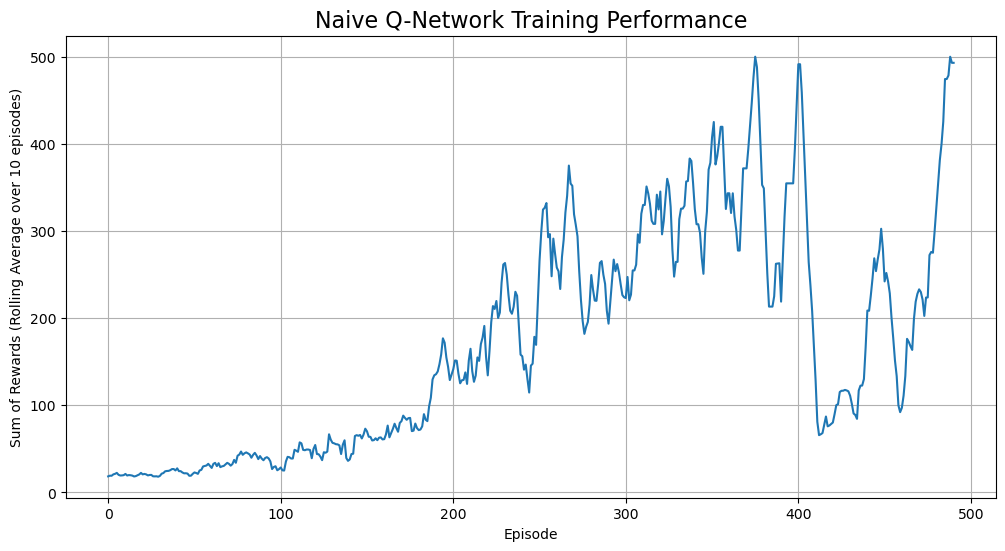

In [16]:
# --- Visualize Results ---
window_size = 10
rolling_avg = np.convolve(naive_rewards_cartpole, np.ones(window_size)/window_size, mode='valid')
plt.figure(figsize=(12, 6))
plt.plot(rolling_avg)
plt.title("Naive Q-Network Training Performance", fontsize=16)
plt.xlabel("Episode")
plt.ylabel(f"Sum of Rewards (Rolling Average over {window_size} episodes)")
plt.grid(True)
plt.show()


Hmm, this seems to be unstable, especially towards the end it seems to "forget" its process. This is actually expected because of two main problems:
1. **Correlated Samples**: The experiences that the agent uses originate from a *sequence* (the MDP). Consecutive states are highly correlated. Neural networks learn best from independent and identically distributed (i.i.d.) data. Training on sequential data is inefficient and can lead to bad feedback loops. It's like trying to learn to identify all types of animals by only looking at 1,000 pictures of cats in a row, followed by 1,000 pictures of dogs. The network doesn't learn to generalize.
2. **Moving Target**: The network's weights, $\theta$, are used to calculate both the *prediction* ($Q(S,A;\theta)$) and the *target* ($R+\gamma\max_{a^{\prime}}Q(S^{\prime},a^{\prime};\theta)$). This means that with every training step, the target value shifts, making convergence hard.

## Deep Q-Networks (DQN)
The following paper was a breakthrough for deep Reinforcement Learning: "Playing Atari with Deep Reinforcement Learning", Mnih et al. (2013), https://arxiv.org/abs/1312.5602

For the first time, a deep learner was able to massively outperform the best linear RL algorithms on the collection of classic Atari games, oftentimes achieving human-level performance or above.

<img src="./images/atari.webp" style="width: 300px;"/>

The two key breakthrougs that helped with stabilizing learning with deep neural networks on MDP environments are:
1. **Experience Replay**: We create a memory buffer (a replay buffer) that stores transititions from the MDP $(S,A,R,S^{\prime})$. Instead of traning on the single last experience, we then sample from this buffer to train on. This allows us to train on more data and is more efficient than training on a single transition at a time. Essentially, we are using mini-batches. This also breaks the the temporal correlation between samples because the replay buffer stores and samples transititions without regard for order.
2. **Target Network**: We create an exact copy of the Q-Network (the target network) that is only used to calculate the TD target. Its weights $\hat{\theta}$ are frozen and only updated periodically (e.g. every 100 steps) by transfering the weights $\theta$ from the main Q-Network. This provides a stable, consistent target (at least for a period of time, the e.g. 100 steps), solving the "moving target" problem. The loss thus becomes:
$$\mathcal{L}(\theta)=\left(R+\gamma\max_{a^{\prime}}Q(S^{\prime},a^{\prime};\hat{\theta})-Q(S,A;\theta)\right)^2$$

The schematic is as follows, which we will now implement!

<img src="./images/dqn_schematic.webp" style="width: 600px;"/>

In [14]:
# --- 1. Replay Buffer ---
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        states, actions, rewards, next_states, dones = zip(*random.sample(self.buffer, batch_size))
        return np.array(states), np.array(actions), np.array(rewards), np.array(next_states), np.array(dones)

    def __len__(self):
        return len(self.buffer)

# --- 2. Q-Network Model ---
class QNetwork(nn.Module):
    def __init__(self, state_size, action_size):
        super(QNetwork, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(state_size, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, action_size)
        )
    def forward(self, x):
        return self.layers(x)

# --- 3. Main Training Script ---
env = gym.make("CartPole-v1")
state_size = env.observation_space.shape[0]
action_size = env.action_space.n

# Hyperparameters
num_episodes = 500
gamma = 0.99
learning_rate = 0.001
epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.01
BUFFER_SIZE = 10000
BATCH_SIZE = 64
TARGET_UPDATE_FREQ = 50

# Initialization
policy_net = QNetwork(state_size, action_size)
target_net = QNetwork(state_size, action_size)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=learning_rate)
memory = ReplayBuffer(BUFFER_SIZE)
loss_function = nn.MSELoss()
episode_rewards_history = []

print("Training DQN Agent on CartPole...")
for episode in range(num_episodes):
    state, info = env.reset()
    total_reward = 0
    done = False
    while not done:
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
                action = policy_net(state_t).max(1)[1].item()
        
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        total_reward += reward

        memory.push(state, action, reward, next_state, done)
        state = next_state

        if len(memory) >= BATCH_SIZE:
            states_b, actions_b, rewards_b, next_states_b, dones_b = memory.sample(BATCH_SIZE)
            
            states_t = torch.tensor(states_b, dtype=torch.float32)
            actions_t = torch.tensor(actions_b, dtype=torch.long).unsqueeze(1)
            rewards_t = torch.tensor(rewards_b, dtype=torch.float32).unsqueeze(1)
            next_states_t = torch.tensor(next_states_b, dtype=torch.float32)
            dones_t = torch.tensor(dones_b, dtype=torch.bool) # No unsqueeze here

            q_values = policy_net(states_t).gather(1, actions_t)
            
            with torch.no_grad():
                # Shape is [BATCH_SIZE]
                next_q_values_target = target_net(next_states_t).max(1)[0]
                # Set future reward to 0 for terminal states
                next_q_values_target[dones_t] = 0.0
                # Unsqueeze to match the shape of q_values
                td_target = rewards_t + (gamma * next_q_values_target.unsqueeze(1))
            
            loss = loss_function(q_values, td_target)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    episode_rewards_history.append(total_reward)
    epsilon = max(min_epsilon, epsilon * epsilon_decay)

    if episode % TARGET_UPDATE_FREQ == 0:
        target_net.load_state_dict(policy_net.state_dict())
    
    if (episode + 1) % 100 == 0:
        print(f"Episode {episode + 1}/{num_episodes}, Last Reward: {total_reward}")

print("Training finished.")

Training DQN Agent on CartPole...
Episode 100/500, Last Reward: 13.0
Episode 200/500, Last Reward: 24.0
Episode 300/500, Last Reward: 231.0
Episode 400/500, Last Reward: 155.0
Episode 500/500, Last Reward: 112.0
Training finished.


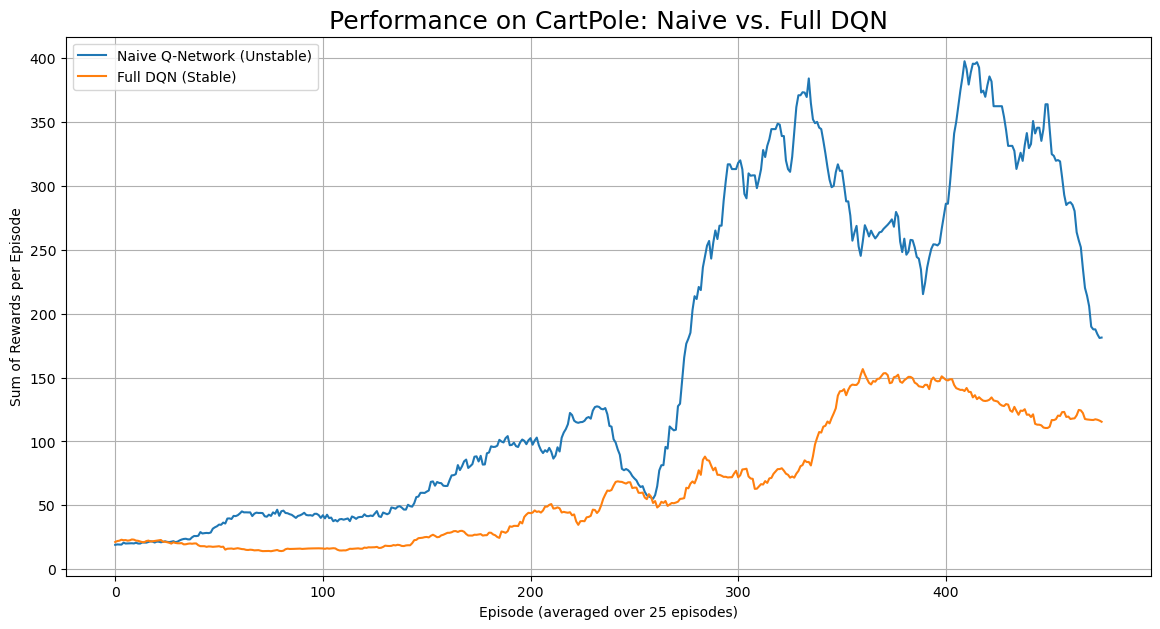

In [15]:
# --- Comparative Visualization ---
window_size = 25 # Use a smaller window to see details
naive_rolling_avg = np.convolve(naive_rewards_cartpole, np.ones(window_size)/window_size, mode='valid')
dqn_rolling_avg = np.convolve(episode_rewards_history, np.ones(window_size)/window_size, mode='valid')

plt.figure(figsize=(14, 7))
plt.plot(naive_rolling_avg, label='Naive Q-Network (Unstable)')
plt.plot(dqn_rolling_avg, label='Full DQN (Stable)')
plt.title('Performance on CartPole: Naive vs. Full DQN', fontsize=18)
plt.xlabel(f'Episode (averaged over {window_size} episodes)')
plt.ylabel('Sum of Rewards per Episode')
plt.legend()
plt.grid(True)
plt.show()

This shows two interesting takeaways!
1. DQN is more stable, but takes longer... it looks like, it could need some more episodes!
2. The naive Q-Network learns much faster, but that's deceptive: At around the 400th episode we see a textbook example of **catastrophic forgetting**: 
    - The naive network learns from sequential, highly correlated experiences. By chance, it might find a good sequence of actions and, without a replay buffer to mix in other experiences, it rapidly overfits to this recent "good" data. This explains the steep, impressive-looking initial learning curve. 
    - The agent's policy becomes very specialized. As it continues to explore, it might eventually encounter a different type of situation where its specialized policy fails. When it gets new, correlated "bad" data from this failure, it overwrites its previously learned weights, leading to a sudden and catastrophic collapse in performance. This is the reason we use *experience replay* in DQN.

Let's run it for more episodes!

Training Naive Q-Network on CartPole...
Naive Q-network training finished.
Training DQN Agent on CartPole...
Episode 200/1000, Last Reward: 19.0
Episode 400/1000, Last Reward: 121.0
Episode 600/1000, Last Reward: 17.0
Episode 800/1000, Last Reward: 201.0
Episode 1000/1000, Last Reward: 234.0
DQN Training finished.


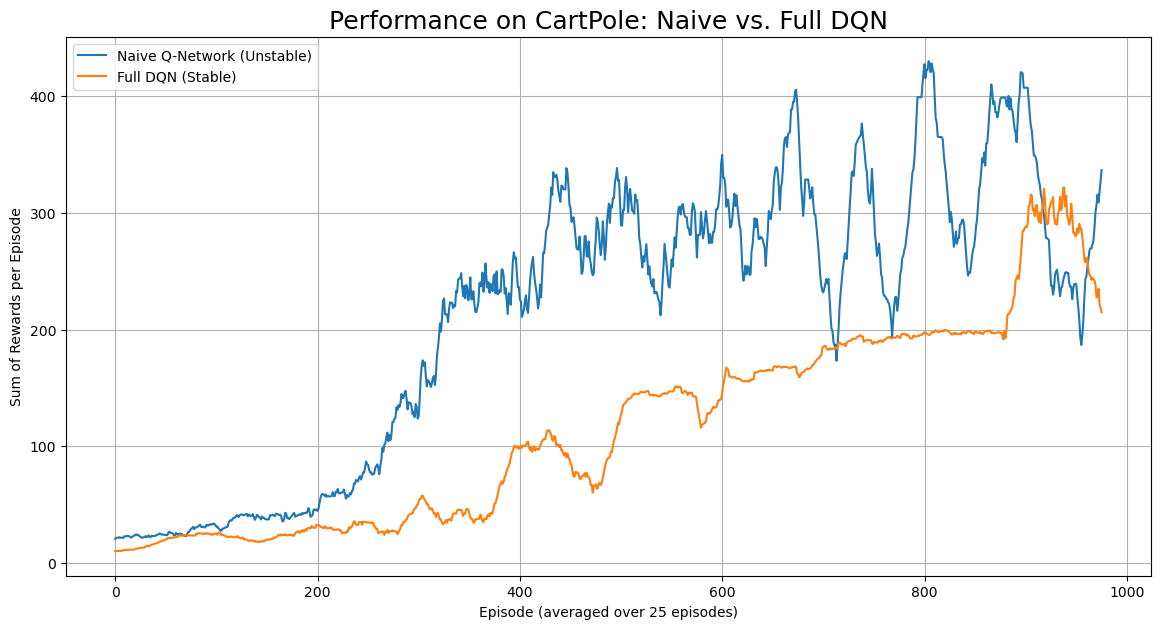

In [ ]:
#### Hyperparameters
num_episodes = 1000
gamma = 0.99
learning_rate = 0.001
epsilon = 1.0
epsilon_decay = 0.9975
min_epsilon = 0.01

###### Naive Q-Network #######

# --- Environment and Network Setup for CartPole ---
env = gym.make("CartPole-v1", render_mode="rgb_array")
state_size = env.observation_space.shape[0] # Should be 4
action_size = env.action_space.n # Should be 2

# --- Train the Naive Network on CartPole ---
naive_model = QNetworkCartPole()
optimizer = optim.Adam(naive_model.parameters(), lr=learning_rate)
loss_function = nn.MSELoss()
naive_rewards_cartpole = []

print("Training Naive Q-Network on CartPole...")
for episode in range(num_episodes):
    state, info = env.reset()
    state = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
    total_reward = 0
    done = False
    while not done:
        with torch.no_grad():
            q_values = naive_model(state)
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = torch.argmax(q_values).item()

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        total_reward += reward

        # The unstable, step-by-step learning process
        next_state_tensor = torch.tensor(next_state, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            # Target is calculated with the same, constantly changing network
            max_next_q = torch.max(naive_model(next_state_tensor))
        td_target = reward + gamma * max_next_q * (1 - int(done))
        
        current_q_value = naive_model(state)[0][action]
        loss = loss_function(current_q_value, td_target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        state = next_state_tensor

    naive_rewards_cartpole.append(total_reward)
    epsilon = max(min_epsilon, epsilon * epsilon_decay)

print("Naive Q-network training finished.")


###### DQN #######
# --- 3. Main Training Script ---
env = gym.make("CartPole-v1", render_mode="rgb_array")
state_size = env.observation_space.shape[0]
action_size = env.action_space.n

# Hyperparameters
BUFFER_SIZE = 10000
BATCH_SIZE = 64
TARGET_UPDATE_FREQ = 100

# Initialization
policy_net = QNetwork(state_size, action_size)
target_net = QNetwork(state_size, action_size)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=learning_rate)
memory = ReplayBuffer(BUFFER_SIZE)
loss_function = nn.MSELoss()
episode_rewards_history = []

print("Training DQN Agent on CartPole...")
for episode in range(num_episodes):
    state, info = env.reset()
    total_reward = 0
    done = False
    while not done:
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
                action = policy_net(state_t).max(1)[1].item()
        
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        total_reward += reward

        memory.push(state, action, reward, next_state, done)
        state = next_state

        if len(memory) >= BATCH_SIZE:
            states_b, actions_b, rewards_b, next_states_b, dones_b = memory.sample(BATCH_SIZE)
            
            states_t = torch.tensor(states_b, dtype=torch.float32)
            actions_t = torch.tensor(actions_b, dtype=torch.long).unsqueeze(1)
            rewards_t = torch.tensor(rewards_b, dtype=torch.float32).unsqueeze(1)
            next_states_t = torch.tensor(next_states_b, dtype=torch.float32)
            dones_t = torch.tensor(dones_b, dtype=torch.bool) # No unsqueeze here

            q_values = policy_net(states_t).gather(1, actions_t)
            
            with torch.no_grad():
                # Shape is [BATCH_SIZE]
                next_q_values_target = target_net(next_states_t).max(1)[0]
                # Set future reward to 0 for terminal states
                next_q_values_target[dones_t] = 0.0
                # Unsqueeze to match the shape of q_values
                td_target = rewards_t + (gamma * next_q_values_target.unsqueeze(1))
            
            loss = loss_function(q_values, td_target)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    episode_rewards_history.append(total_reward)
    epsilon = max(min_epsilon, epsilon * epsilon_decay)

    if episode % TARGET_UPDATE_FREQ == 0:
        target_net.load_state_dict(policy_net.state_dict())
    
    if (episode + 1) % 200 == 0:
        print(f"Episode {episode + 1}/{num_episodes}, Last Reward: {total_reward}")

print("DQN Training finished.")

# --- Comparative Visualization ---
window_size = 25 # Use a smaller window to see details
naive_rolling_avg = np.convolve(naive_rewards_cartpole, np.ones(window_size)/window_size, mode='valid')
dqn_rolling_avg = np.convolve(episode_rewards_history, np.ones(window_size)/window_size, mode='valid')

plt.figure(figsize=(14, 7))
plt.plot(naive_rolling_avg, label='Naive Q-Network (Unstable)')
plt.plot(dqn_rolling_avg, label='Full DQN (Stable)')
plt.title('Performance on CartPole: Naive vs. Full DQN', fontsize=18)
plt.xlabel(f'Episode (averaged over {window_size} episodes)')
plt.ylabel('Sum of Rewards per Episode')
plt.legend()
plt.grid(True)
plt.show()

## Know the Theory, Use the Tools: StableBaselines3
We had to implement the TD update, the loss function, the training loop, and the neural network all from scratch. While this is important to understand the algorithms, but it's also important to capitalize on tools that are available to us as researchers. You don't need to reinvent the wheel all the time ;-)

`stablebaselines3` is a library that provides "reliable / robust implementations of popular RL algorithms" and can interact with `gymnasium` directly: https://github.com/DLR-RM/stable-baselines3

We can implement DQN in the `CartPole` environment in just a couple of lines of code:


In [ ]:
from stable_baselines3 import DQN

# 1. Create the environment
env = gym.make("CartPole-v1", render_mode="rgb_array")

# 2. Instantiate the DQN agent with a Multi-Layer Perceptron (Mlp) policy
model = DQN("MlpPolicy", env, verbose=1, 
            learning_rate=0.001, 
            buffer_size=10000, 
            learning_starts=500,
            batch_size=32,
            gamma=0.99,
            train_freq=(4, "step"),
            target_update_interval=1000,
            exploration_fraction=0.1,
            exploration_final_eps=0.05
           )

# 3. Train the model
model.learn(total_timesteps=50000)

# 4. (Optional) Save the trained model
model.save("dqn_cartpole")

print("Training complete, Model saved as `dqn_cartpole`!")

We can evaluate using the provided `evaluate_policy` function:

In [12]:
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor

# Evaluate the trained agent
# Separate env for evaluation
eval_env = Monitor(gym.make("CartPole-v1")) # need to wrap it in Monitor to silence warnings
mean_reward, std_reward = evaluate_policy(model, eval_env, n_eval_episodes=10, deterministic=True)

print(f"mean_reward={mean_reward:.2f} +/- {std_reward}")

mean_reward=150.90 +/- 6.579513659838392


Then, we or somebody else (with the same versions of sb3 and gym) can load the trained model and use it to run an agent without ever needing to train!

In [ ]:
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# --- Load the saved model ---
# We need to create a new environment instance for the loaded model
env_vis = gym.make("CartPole-v1", render_mode='rgb_array')
loaded_model = DQN.load("dqn_cartpole", env=env_vis)

# --- Run an episode and collect frames ---
frames = []
state, info = env_vis.reset()
done = False
while not done:
    frames.append(env_vis.render())
    # Use the model to predict the best action (deterministic=True)
    action, _states = loaded_model.predict(state, deterministic=True)
    state, reward, terminated, truncated, info = env_vis.step(action)
    done = terminated or truncated
env_vis.close()

# --- Create and display animation ---
fig = plt.figure(figsize=(4, 4))
plt.axis('off')
patch = plt.imshow(frames[0])
def animate(i):
    patch.set_data(frames[i])
    return patch,
anim = FuncAnimation(fig, animate, frames=len(frames), interval=30, blit=True)
plt.close(fig)

HTML(anim.to_html5_video())

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


**Takeaway**:
- Build from scratch (like we just did): To learn the fundamental principles, to debug, to understand the failure modes, and when you need to create a novel algorithm.
- Use a library (like SB3): For rapid prototyping, for benchmarking against established results, and for applying RL to new problems without getting bogged down in implementation details.

## Exercise: LunarLander Environment

We've seen that in the pretty simple `CartPole` environment a simple Q-Network performs okay and the DQN performs more robust, but how does it compare in the `LunarLander` environment?

Environment: https://gymnasium.farama.org/environments/box2d/lunar_lander/

The environment is interesting in that it has a relatively simple action space of 4 discrete actions, but a complex observation space of 8 continuous features.

**Action Space**
- 0: do nothing
- 1: fire left orientation engine
- 2: fire main engine
- 3: fire right orientation engine

**Observation Space**
An 8-tuple of:
- The coordinates of the lander in x & y, 
- Its linear velocities in x & y, 
- Its angle,
- Its angular velocity,
- Two booleans that represent whether each leg is in contact with the ground or not

<img src="./images/lunar_lander.gif" style="width: 400px;"/>

**Tasks:**
1. Reimplement the naive Q-Network for the LunarLander environment. *Hint:* You need to account for the fact that the input is 8-dimensional and the output is 4-dimensional.
1. Train the SB3 DQN for the LunarLander environment.
1. Evaluate both agents and compare the performance.


We provide you with a function for evaluation of the two agents below:

In [9]:
def evaluate_agent(env_name, agent, agent_type, n_episodes=100):
    """
    Evaluates a given agent (SB3 or PyTorch) on a gym environment.
    
    Args:
        env_name (str): Name of the environment.
        agent: The trained agent/model.
        agent_type (str): Type of agent: 'sb3', 'pytorch'.
        n_episodes (int): Number of episodes to run for evaluation.
        
    Returns:
        A tuple of (mean_reward, std_reward).
    """
    eval_env = gym.make(env_name)
    episode_rewards = []
    
    for _ in range(n_episodes):
        state, info = eval_env.reset()
        done = False
        total_reward = 0
        while not done:
            if agent_type == 'sb3':
                action, _ = agent.predict(state, deterministic=True)
            elif agent_type == 'pytorch':
                state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
                with torch.no_grad():
                    action = agent(state_t).max(1)[1].item()
            else:
                raise ValueError("Unknown agent_type")
                
            state, reward, terminated, truncated, info = eval_env.step(action)
            done = terminated or truncated
            total_reward += reward
        episode_rewards.append(total_reward)
        
    eval_env.close()
    mean_reward = np.mean(episode_rewards)
    std_reward = np.std(episode_rewards)
    return mean_reward, std_reward

You can use it like this:

In [ ]:
# --- Running the Comparison ---

##################
#                #
# YOUR CODE HERE #
#                #
##################

# We assume your trained models are in memory and named like this, otherwise adapt:
# naive_model -> The naive PyTorch Q-Network
# sb3_model -> The stable-baselines3 DQN model

mean_naive, std_naive = evaluate_agent("LunarLander-v3", naive_model, 'pytorch')
print(f"  - Naive PyTorch Net -> Mean reward: {mean_naive:.2f} +/- {std_naive:.2f}")

mean_sb3, std_sb3 = evaluate_policy(sb3_model, Monitor(gym.make("LunarLander-v3")))
print(f"  - Stable-Baselines3 -> Mean reward: {mean_sb3:.2f} +/- {std_sb3:.2f}")

### naive Q-network

In [11]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# --- Environment Setup ---
env = gym.make("LunarLander-v3", render_mode="rgb_array")
state_size = env.observation_space.shape[0] # 8
action_size = env.action_space.n # 4

# --- Network and Hyperparameters ---
class QNetwork(nn.Module):
    def __init__(self):
        super(QNetwork, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(state_size, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, action_size)
        )
    def forward(self, x):
        return self.layers(x)

num_episodes = 1000
gamma = 0.99
learning_rate = 0.001
epsilon = 1.0
epsilon_decay = 0.999
min_epsilon = 0.01

# --- Naive Training Loop ---
naive_model = QNetwork()
optimizer = optim.Adam(naive_model.parameters(), lr=learning_rate)
loss_function = nn.MSELoss()
naive_lunar_rewards = []

print("Training Naive Q-Network on LunarLander...")
for episode in range(num_episodes):
    state, info = env.reset()
    total_reward = 0
    done = False
    while not done:
        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            q_values = naive_model(state_t)
        action = np.argmax(q_values).item() if np.random.random() > epsilon else env.action_space.sample()
        
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        total_reward += reward

        next_state_t = torch.tensor(next_state, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            max_next_q = torch.max(naive_model(next_state_t))
        td_target = reward + gamma * max_next_q * (1 - int(done))
        
        current_q = naive_model(state_t)[0][action]
        loss = loss_function(current_q, td_target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        state = next_state

    naive_lunar_rewards.append(total_reward)
    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    if (episode + 1) % 200 == 0:
        print(f"Episode {episode + 1}/{num_episodes} finished.")

print("Training finished.")

Training Naive Q-Network on LunarLander...
Episode 200/1000 finished.
Episode 400/1000 finished.
Episode 600/1000 finished.
Episode 800/1000 finished.
Episode 1000/1000 finished.
Training finished.


### DQN

In [12]:
from stable_baselines3 import DQN
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor

# --- Train and Evaluate the SB3 Agent ---
# Wrap the environment in a Monitor to collect stats
train_env = Monitor(gym.make("LunarLander-v3"))

# Instantiate the model. SB3's DQN has tuned defaults.
sb3_model = DQN("MlpPolicy", train_env, batch_size=128, buffer_size=50_000, gamma=gamma, target_update_interval=250, train_freq=4, gradient_steps=-1, exploration_fraction=0.12, exploration_final_eps=0.1, policy_kwargs={"net_arch": [256,256]})

# Train for 1,000,000 timesteps
print("\nTraining Stable-Baselines3 DQN on LunarLander...")
sb3_model.learn(total_timesteps=1_000_000, log_interval=10)
print("Training finished.")


Training Stable-Baselines3 DQN on LunarLander...
Training finished.


In [13]:
# We assume your trained models are in memory and named like this, otherwise adapt:
# naive_model -> The naive PyTorch Q-Network
# sb3_model -> The stable-baselines3 DQN model

mean_naive, std_naive = evaluate_agent("LunarLander-v3", naive_model, 'pytorch')
print(f"  - Naive PyTorch Net -> Mean reward: {mean_naive:.2f} +/- {std_naive:.2f}")

mean_sb3, std_sb3 = evaluate_policy(sb3_model, Monitor(gym.make("LunarLander-v3")))
print(f"  - Stable-Baselines3 -> Mean reward: {mean_sb3:.2f} +/- {std_sb3:.2f}")

  - Naive PyTorch Net -> Mean reward: -775.61 +/- 710.97
  - Stable-Baselines3 -> Mean reward: 245.86 +/- 80.19


Let's watch the agent in action!

In [16]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# --- Animate the successful SB3 agent ---
print("\nAnimating trained SB3 agent...")
vis_env = gym.make("LunarLander-v3", render_mode='rgb_array')
frames = []
state, info = vis_env.reset()
done = False
while not done:
    frames.append(vis_env.render())
    action, _ = sb3_model.predict(state, deterministic=True)
    state, reward, terminated, truncated, info = vis_env.step(action)
    done = terminated or truncated
vis_env.close()

# Create and display animation
fig = plt.figure(figsize=(6, 6))
plt.axis('off')
plt.tight_layout()
patch = plt.imshow(frames[0])
def animate(i):
    patch.set_data(frames[i])
    return patch,
anim = FuncAnimation(fig, animate, frames=len(frames), interval=30, blit=True)
plt.close(fig)

HTML(anim.to_html5_video())


Animating trained SB3 agent...
